# Benchmark Properties

Value tensions, physician agreement, and entropy analysis.

In [10]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.colors import ListedColormap

from src.analysis import (
    load_all_decisions,
    human_consensus,
    HUMAN_CONSENSUS,
    case_entropy_correlation,
    entropy_per_case,
    entropy_statistics,
    value_tension_pairs,
    fleiss_kappa,
    build_kappa_input_table,
)
from src.response_models.case import VALUE_NAMES

from pathlib import Path
LLM_DIR = Path(DIR) / "data" / "llm_decisions" / "physician_recommendation"

sns.set_theme(style="whitegrid", palette="deep")

all_decisions = load_all_decisions(llm_dir=LLM_DIR)
decisions = [r for r in all_decisions if any(m.startswith("human/") for m in r.models)]

llm_models = sorted({m for r in decisions for m in r.models if not m.startswith("human/")})
human_participants = sorted({m for r in decisions for m in r.models if m.startswith("human/")})
models = llm_models + [HUMAN_CONSENSUS]

print(f"Cases: {len(decisions)} | LLMs: {len(llm_models)} | Physicians: {len(human_participants)}")

Cases: 50 | LLMs: 12 | Physicians: 20


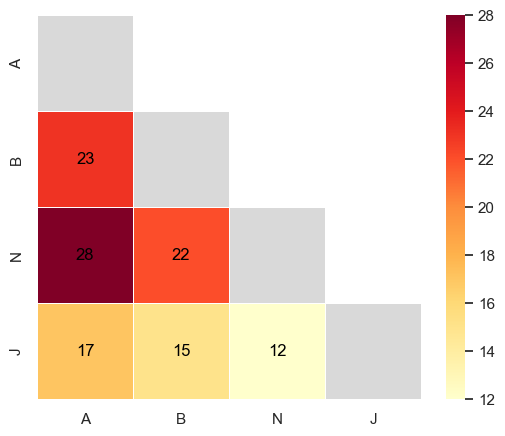

In [11]:
values = ["autonomy", "beneficence", "nonmaleficence", "justice"]
tension_counts = pd.DataFrame(0, index=values, columns=values)

for record in decisions:
    for x, y in value_tension_pairs(record.case):
        tension_counts.loc[x, y] += 1
        tension_counts.loc[y, x] += 1

mask_upper = np.triu(np.ones(len(values), dtype=bool), k=1)
mask_diag = np.eye(len(values), dtype=bool)
display_labels = [v[0].upper() for v in values]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    tension_counts.values,
    mask=mask_upper | mask_diag,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    square=True,
    linewidths=0.5,
    annot_kws={"color": "black"},
    xticklabels=display_labels,
    yticklabels=display_labels,
    ax=ax,
)
sns.heatmap(
    np.ones_like(tension_counts.values, dtype=float),
    mask=~mask_diag,
    cmap=ListedColormap(["#d9d9d9"]),
    cbar=False,
    annot=False,
    square=True,
    linewidths=0.5,
    xticklabels=display_labels,
    yticklabels=display_labels,
    ax=ax,
)
# ax.set_title("Value Tension Co-occurrence")
ax.grid(False)
plt.tight_layout()
plt.show()

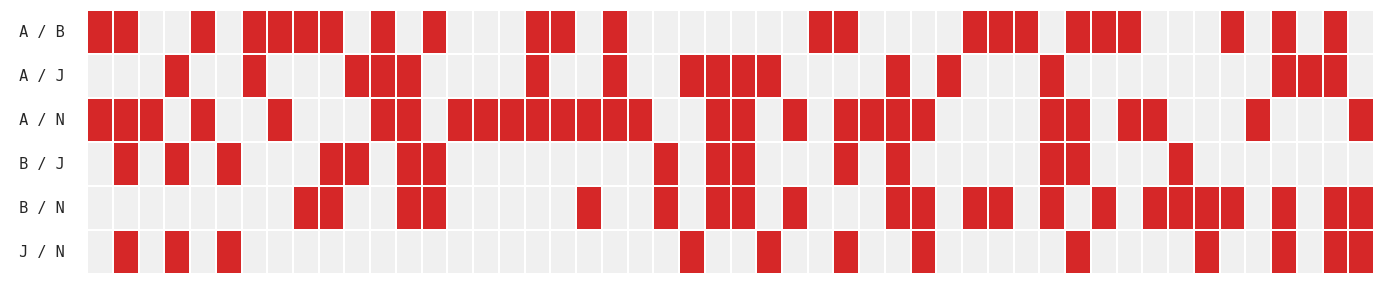

In [12]:
all_pairs = list(combinations(sorted(VALUE_NAMES), 2))
pair_labels = [f" {a.capitalize()[0]} / {b.capitalize()[0]} " for a, b in all_pairs]

tension_matrix = pd.DataFrame(0, index=pair_labels, columns=range(len(decisions)))

for col, record in enumerate(decisions):
    for pair in value_tension_pairs(record.case):
        label = f" {pair[0].capitalize()[0]} / {pair[1].capitalize()[0]} "
        tension_matrix.loc[label, col] = 1

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    tension_matrix,
    cmap=ListedColormap(["#f0f0f0", "#d62728"]),
    cbar=False,
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    xticklabels=False,
)
# ax.set_ylabel("")
# ax.set_xlabel(f"Cases (n = {len(decisions)})")
# ax.set_title("Value Tensions per Case")
ax.set_yticklabels(ax.get_yticklabels(), fontfamily='monospace')
plt.tight_layout()
plt.show()

In [13]:
consensus = human_consensus(decisions)

THRESHOLD = 0.70
confidences = [c.confidence for c in consensus.values() if c.confidence is not None]
n_below = sum(1 for c in confidences if c < THRESHOLD)
median_plurality = float(np.median(confidences))

print(f"Jury pluralism (n = {len(confidences)} cases)")
print(f"  Cases below {THRESHOLD:.0%} endorsement threshold: {n_below}/{len(confidences)}")
print(f"  Median plurality share: {median_plurality:.1%}")

Jury pluralism (n = 50 cases)
  Cases below 70% endorsement threshold: 21/50
  Median plurality share: 70.0%


In [14]:
table, kappa_case_ids = build_kappa_input_table(decisions, human_participants)
kappa = fleiss_kappa(table)

print(f"Fleiss' kappa for physician panel")
print(f"  Raters: {len(human_participants)}, Cases: {len(kappa_case_ids)}")
print(f"  κ = {kappa:.4f}")

Fleiss' kappa for physician panel
  Raters: 20, Cases: 50
  κ = 0.2361


In [15]:
print("Model decision stability (entropy of response distribution):\n")
for model in llm_models:
    stats = entropy_statistics(decisions, model)
    name = model.split("/")[-1]
    print(f"  {name:30s}  mean={stats.mean:.3f}  median={stats.median:.3f}  n={stats.n_cases}")

human_stats = entropy_statistics(decisions, HUMAN_CONSENSUS)
print(f"\nPhysician normative ambiguity (aggregated vote entropy):")
print(f"  mean={human_stats.mean:.3f}  median={human_stats.median:.3f}  n={human_stats.n_cases}")

Model decision stability (entropy of response distribution):

  claude-opus-4.5                 mean=0.173  median=0.000  n=50
  ernie-4.5-vl-424b-a47b          mean=0.293  median=0.000  n=50
  deepseek-chat                   mean=0.294  median=0.000  n=50
  gemini-3-pro-preview            mean=0.129  median=0.000  n=50
  llama-4-maverick                mean=0.348  median=0.000  n=50
  mistral-large-2512              mean=0.105  median=0.000  n=50
  kimi-k2-thinking                mean=0.248  median=0.000  n=50
  gpt-5.2                         mean=0.190  median=0.000  n=50
  sonar-pro                       mean=0.098  median=0.000  n=50
  qwen3-max                       mean=0.095  median=0.000  n=50
  grok-4                          mean=0.205  median=0.000  n=50
  glm-4.6                         mean=0.390  median=0.469  n=50

Physician normative ambiguity (aggregated vote entropy):
  mean=0.759  median=0.881  n=50


## Case-Level Distributional Pluralism

In [16]:
corr_results: dict[str, object] = {}
for model in llm_models:
    corr_results[model] = case_entropy_correlation(decisions, model)

physician_entropy = entropy_per_case(decisions, HUMAN_CONSENSUS)

rows = []
for model, res in corr_results.items():
    rows.append({
        "Model": model.split("/")[-1],
        "Spearman ρ": f"{res.spearman_rho:.3f}",
        "p-value": f"{res.spearman_pvalue:.4f}",
        "n": res.n_cases,
    })

corr_df = pd.DataFrame(rows)
display(corr_df.to_string(index=False))

rhos = [res.spearman_rho for res in corr_results.values()]
print(f"\nSpearman ρ across {len(rhos)} models:")
print(f"  Mean = {np.mean(rhos):.3f}   Range = [{min(rhos):.3f}, {max(rhos):.3f}]")

print(f"\nCorrelations are near zero for all {len(rhos)} models "
      f"(mean ρ = {np.mean(rhos):.3f}, range {min(rhos):.3f} to {max(rhos):.3f}),"
      f" indicating physician disagreement does not predict model uncertainty.")

'                 Model Spearman ρ p-value  n\n       claude-opus-4.5      0.195  0.1737 50\nernie-4.5-vl-424b-a47b      0.073  0.6151 50\n         deepseek-chat     -0.071  0.6232 50\n  gemini-3-pro-preview     -0.109  0.4496 50\n      llama-4-maverick     -0.081  0.5778 50\n    mistral-large-2512      0.051  0.7260 50\n      kimi-k2-thinking     -0.045  0.7582 50\n               gpt-5.2     -0.180  0.2114 50\n             sonar-pro     -0.008  0.9534 50\n             qwen3-max     -0.132  0.3619 50\n                grok-4      0.179  0.2143 50\n               glm-4.6     -0.129  0.3707 50'


Spearman ρ across 12 models:
  Mean = -0.021   Range = [-0.180, 0.195]

Correlations are near zero for all 12 models (mean ρ = -0.021, range -0.180 to 0.195), indicating physician disagreement does not predict model uncertainty.


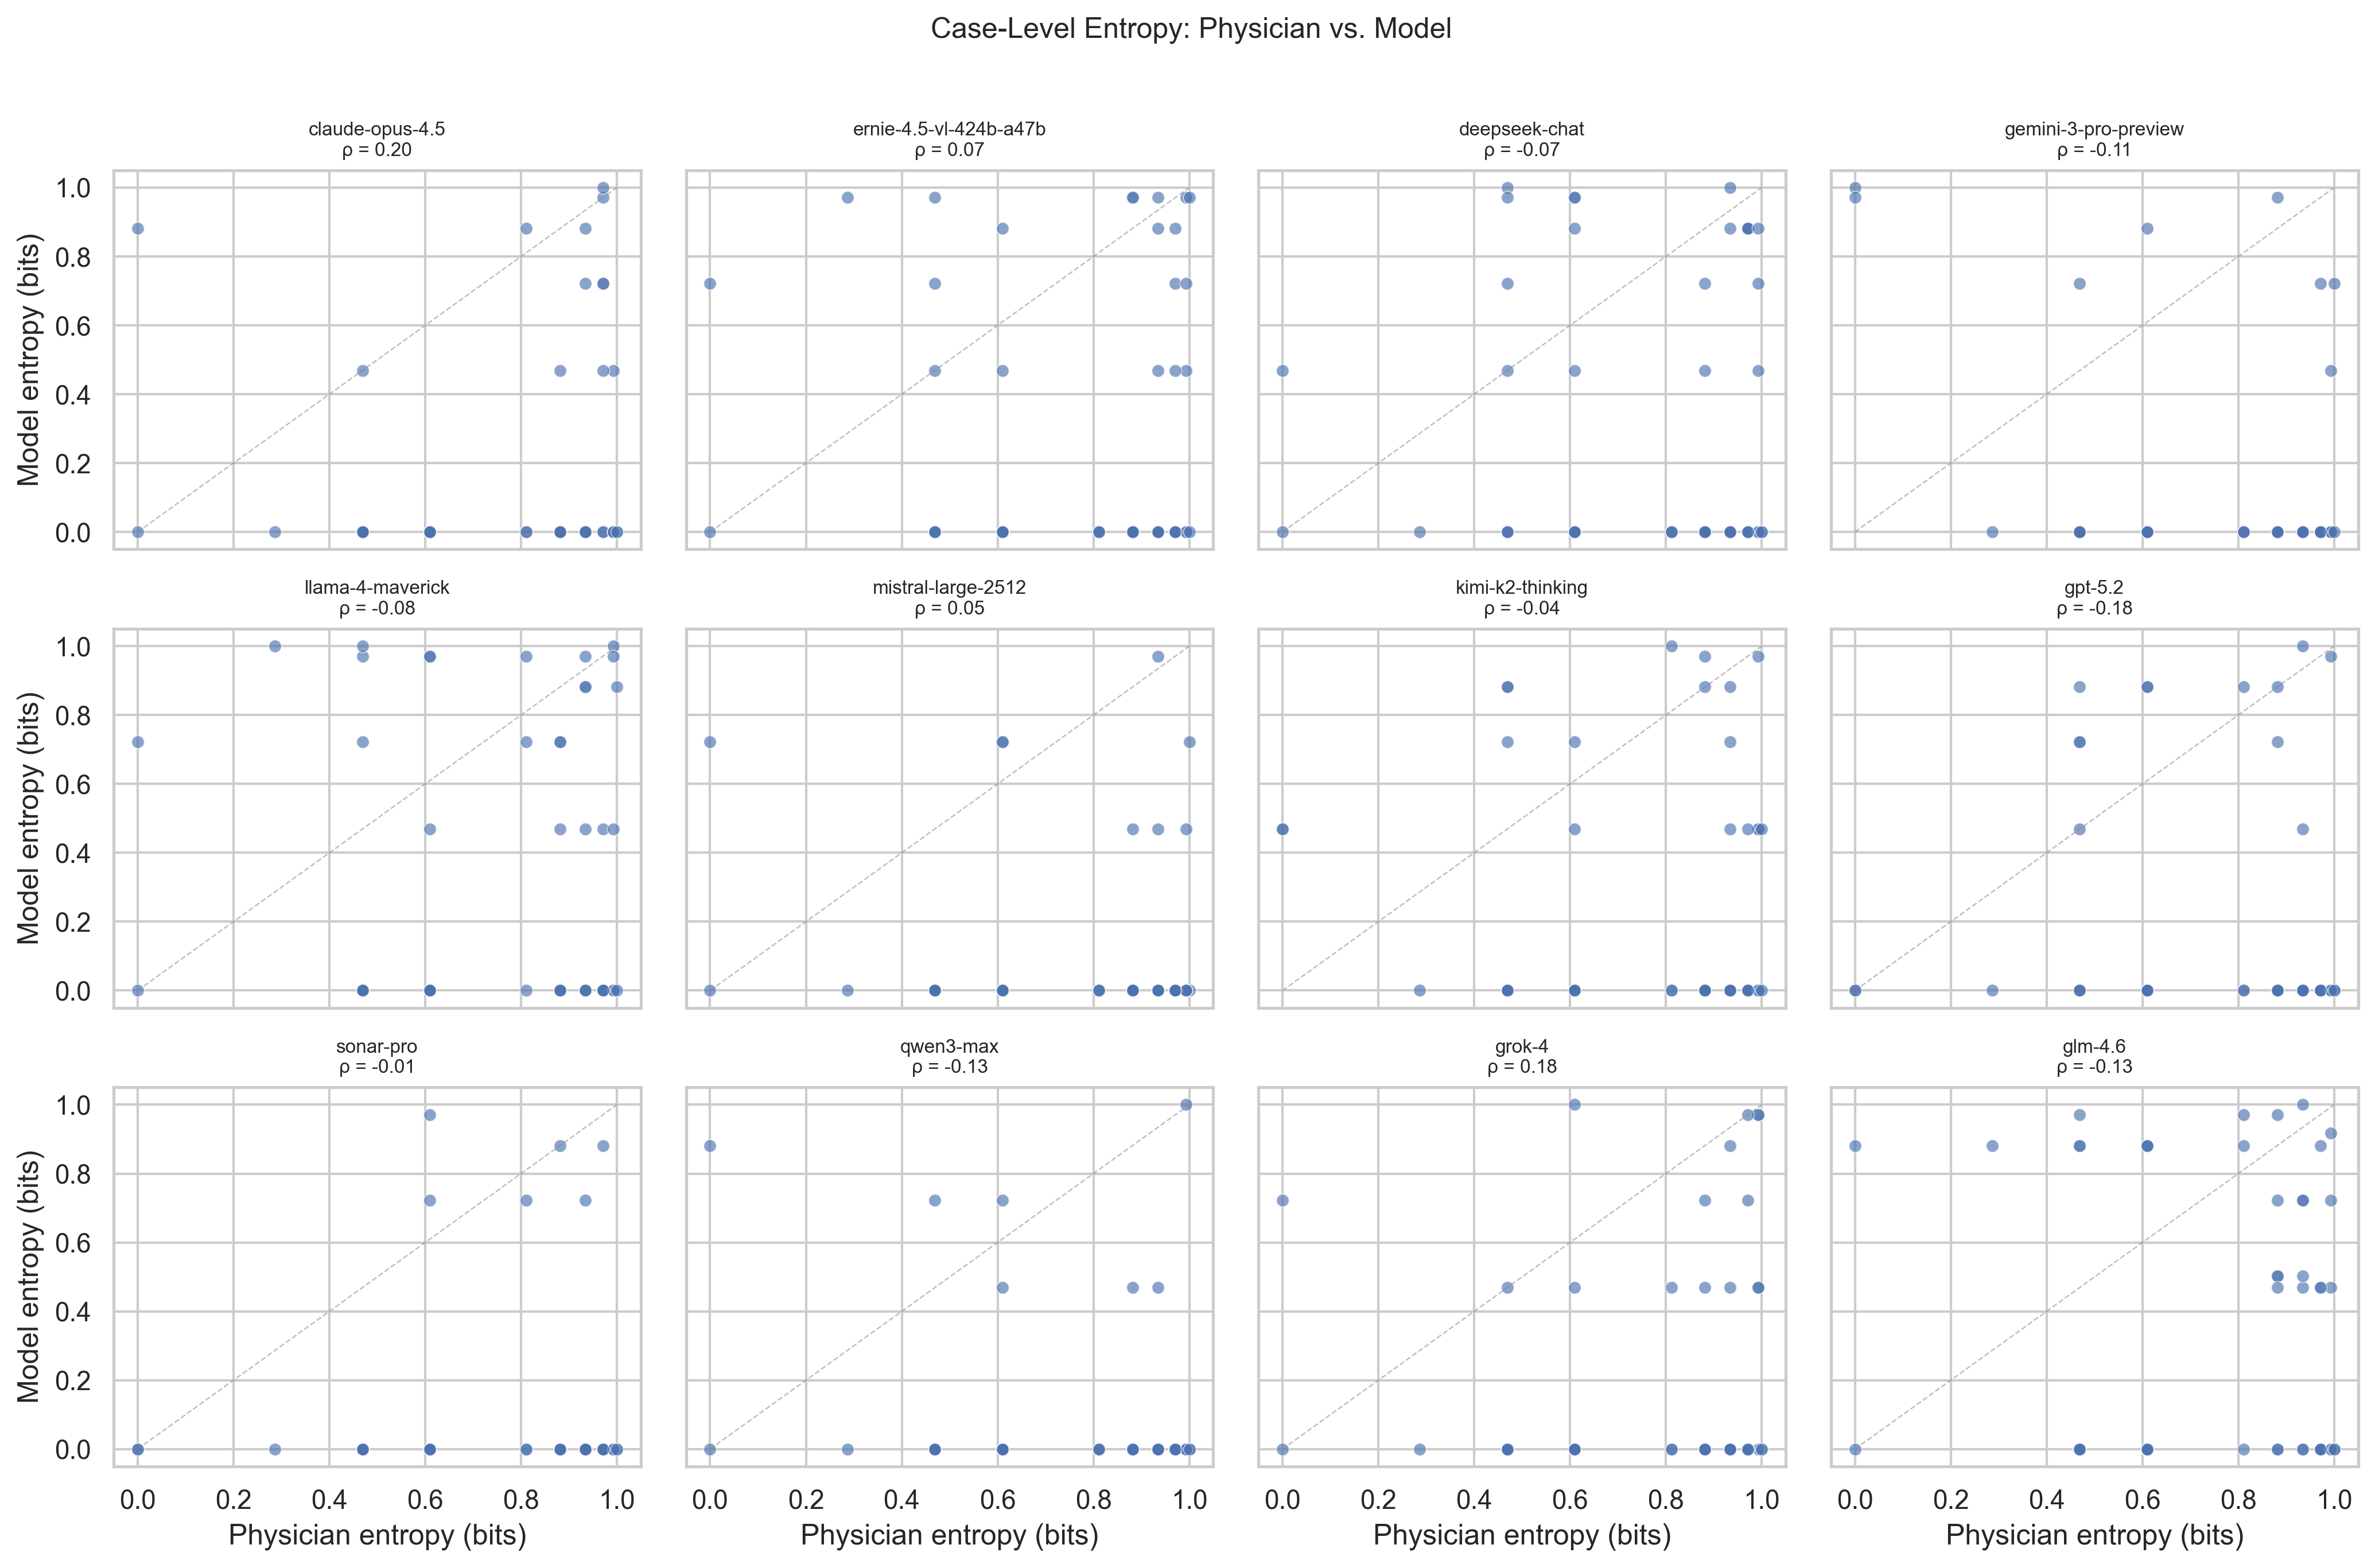

In [17]:
n_models = len(llm_models)
ncols, nrows = 4, 3

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 9), dpi=300,
                         sharex=True, sharey=True)

for idx, (model, ax) in enumerate(zip(llm_models, axes.flat)):
    res = corr_results[model]
    ax.scatter(res.reference_entropies, res.model_entropies,
               s=28, alpha=0.65, edgecolors="white", linewidths=0.4)
    short_name = model.split("/")[-1]
    ax.set_title(f"{short_name}\nρ = {res.spearman_rho:.2f}", fontsize=8)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.plot([0, 1], [0, 1], ls="--", lw=0.6, color="grey", alpha=0.5)

for ax in axes[-1, :]:
    ax.set_xlabel("Physician entropy (bits)")
for ax in axes[:, 0]:
    ax.set_ylabel("Model entropy (bits)")

for ax in axes.flat[n_models:]:
    ax.set_visible(False)

fig.suptitle("Case-Level Entropy: Physician vs. Model", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

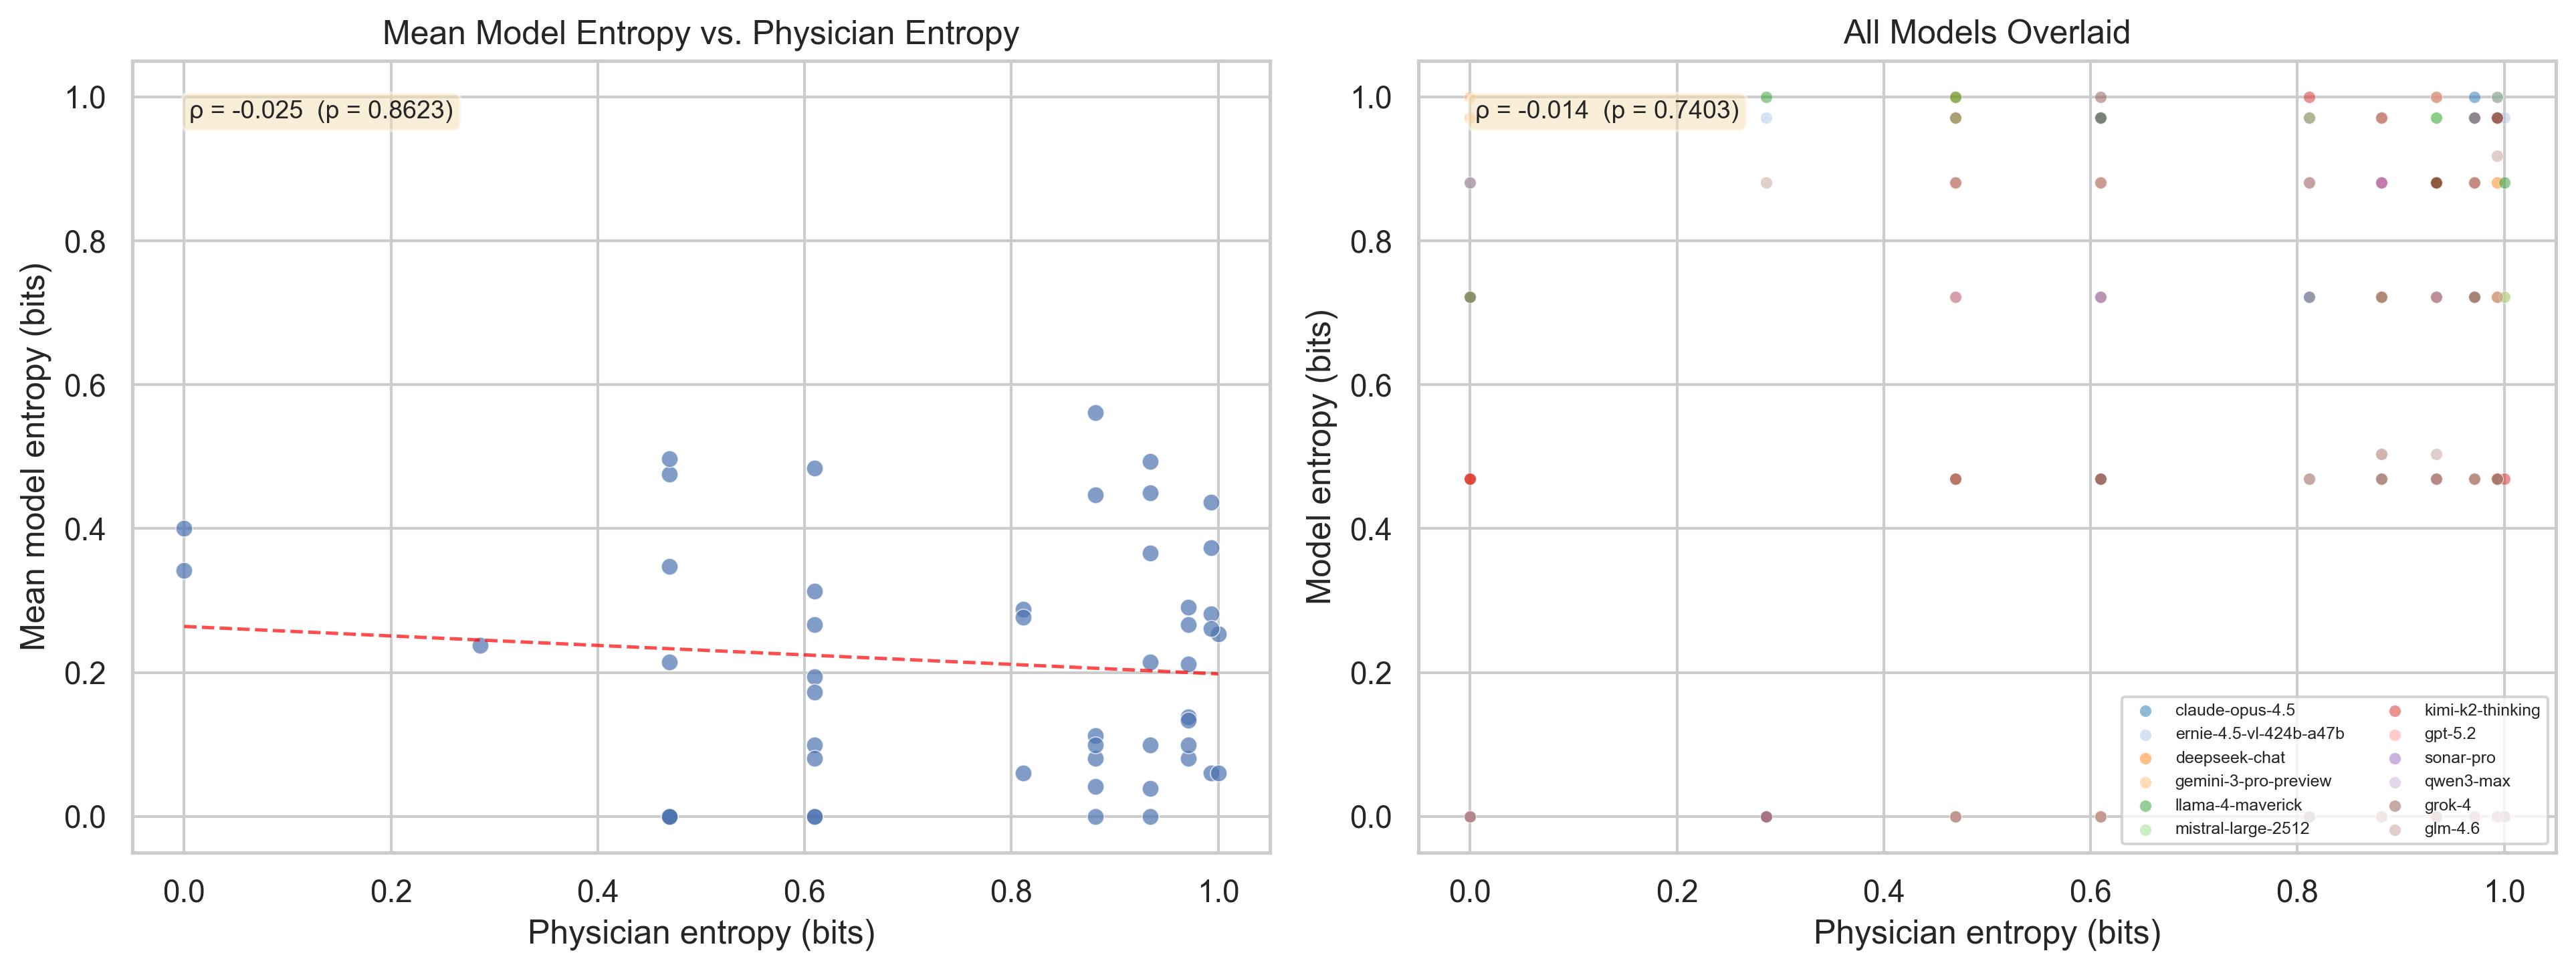

In [18]:
from scipy.stats import spearmanr

common_ids = set(corr_results[llm_models[0]].case_ids)
for model in llm_models[1:]:
    common_ids &= set(corr_results[model].case_ids)
common_ids = sorted(common_ids)

model_entropy_matrix = np.zeros((len(common_ids), len(llm_models)))
for j, model in enumerate(llm_models):
    id_to_ent = dict(zip(corr_results[model].case_ids,
                         corr_results[model].model_entropies))
    for i, cid in enumerate(common_ids):
        model_entropy_matrix[i, j] = id_to_ent[cid]

mean_model_ent = model_entropy_matrix.mean(axis=1)
phys_ent = np.array([physician_entropy[cid] for cid in common_ids])
rho_mean, p_mean = spearmanr(phys_ent, mean_model_ent)

all_phys, all_model = [], []
all_labels = []
for model in llm_models:
    res = corr_results[model]
    all_phys.extend(res.reference_entropies)
    all_model.extend(res.model_entropies)
    all_labels.extend([model.split("/")[-1]] * len(res.reference_entropies))

all_phys = np.array(all_phys)
all_model = np.array(all_model)
all_labels = np.array(all_labels)
rho_all, p_all = spearmanr(all_phys, all_model)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

ax1.scatter(phys_ent, mean_model_ent, s=36, alpha=0.7,
            edgecolors="white", linewidths=0.4)
z = np.polyfit(phys_ent, mean_model_ent, 1)
x_line = np.linspace(0, 1, 100)
ax1.plot(x_line, np.polyval(z, x_line), ls="--", color="red", lw=1.2, alpha=0.7)
ax1.set_xlabel("Physician entropy (bits)")
ax1.set_ylabel("Mean model entropy (bits)")
ax1.set_title("Mean Model Entropy vs. Physician Entropy")
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.annotate(f"ρ = {rho_mean:.3f}  (p = {p_mean:.4f})",
             xy=(0.05, 0.95), xycoords="axes fraction", fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))

palette = sns.color_palette("tab20", n_colors=len(llm_models))
model_names = [m.split("/")[-1] for m in llm_models]
color_map = dict(zip(model_names, palette))

for name in model_names:
    mask = all_labels == name
    ax2.scatter(all_phys[mask], all_model[mask], s=18, alpha=0.5,
                label=name, color=color_map[name],
                edgecolors="white", linewidths=0.2)

ax2.set_xlabel("Physician entropy (bits)")
ax2.set_ylabel("Model entropy (bits)")
ax2.set_title("All Models Overlaid")
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.annotate(f"ρ = {rho_all:.3f}  (p = {p_all:.4f})",
             xy=(0.05, 0.95), xycoords="axes fraction", fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))
ax2.legend(fontsize=6, loc="lower right", ncol=2, framealpha=0.8)

plt.tight_layout()
plt.show()